In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)



In [2]:
# ── Cell 2 — Load All CSV Files ───────────────────────────────────────
orders     = pd.read_csv(r'/Users/anish/Documents/demand forcasting time series /data/raw/orders.csv',     encoding='latin1')
stores     = pd.read_csv(r'/Users/anish/Documents/demand forcasting time series /data/raw/stores.csv',     encoding='latin1')
hubs       = pd.read_csv(r'/Users/anish/Documents/demand forcasting time series /data/raw/hubs.csv',       encoding='latin1')
drivers    = pd.read_csv(r'/Users/anish/Documents/demand forcasting time series /data/raw/drivers.csv',    encoding='latin1')
deliveries = pd.read_csv(r'/Users/anish/Documents/demand forcasting time series /data/raw/deliveries.csv', encoding='latin1')
payments   = pd.read_csv(r'/Users/anish/Documents/demand forcasting time series /data/raw/payments.csv',   encoding='latin1')
channels   = pd.read_csv(r'/Users/anish/Documents/demand forcasting time series /data/raw/channels.csv',   encoding='latin1')

In [3]:
tables = {
    "orders": orders,
    "stores": stores,
    "hubs": hubs,
    "drivers": drivers,
    "deliveries": deliveries,
    "payments": payments,
    "channels": channels,
}

for name, df in tables.items():
    print(f"\n=== {name.upper()} {df.shape} ===")
    print(list(df.columns))


=== ORDERS (368999, 29) ===
['order_id', 'store_id', 'channel_id', 'payment_order_id', 'delivery_order_id', 'order_status', 'order_amount', 'order_delivery_fee', 'order_delivery_cost', 'order_created_hour', 'order_created_minute', 'order_created_day', 'order_created_month', 'order_created_year', 'order_moment_created', 'order_moment_accepted', 'order_moment_ready', 'order_moment_collected', 'order_moment_in_expedition', 'order_moment_delivering', 'order_moment_delivered', 'order_moment_finished', 'order_metric_collected_time', 'order_metric_paused_time', 'order_metric_production_time', 'order_metric_walking_time', 'order_metric_expediton_speed_time', 'order_metric_transit_time', 'order_metric_cycle_time']

=== STORES (951, 7) ===
['store_id', 'hub_id', 'store_name', 'store_segment', 'store_plan_price', 'store_latitude', 'store_longitude']

=== HUBS (32, 6) ===
['hub_id', 'hub_name', 'hub_city', 'hub_state', 'hub_latitude', 'hub_longitude']

=== DRIVERS (4824, 3) ===
['driver_id', 'dri

In [4]:
orders['order_status'].value_counts()


order_status
FINISHED    352020
CANCELED     16979
Name: count, dtype: int64

In [5]:
orders[orders['order_id']==68410055]

,order_id,store_id,channel_id,payment_order_id,delivery_order_id,order_status,order_amount,order_delivery_fee,order_delivery_cost,order_created_hour,order_created_minute,order_created_day,order_created_month,order_created_year,order_moment_created,order_moment_accepted,order_moment_ready,order_moment_collected,order_moment_in_expedition,order_moment_delivering,order_moment_delivered,order_moment_finished,order_metric_collected_time,order_metric_paused_time,order_metric_production_time,order_metric_walking_time,order_metric_expediton_speed_time,order_metric_transit_time,order_metric_cycle_time
8,68410055,2181,35,68410055,68410055,FINISHED,394.80,0.01,6.00,2,32,1,1,2021,1/1/2021 2:32:51 AM,1/1/2021 2:33:00 AM,1/2/2021 6:24:06 PM,1/2/2021 6:30:44 PM,1/2/2021 6:31:15 PM,1/2/2021 6:35:49 PM,NaN,1/2/2021 6:57:34 PM,6.63,4.55,2391.25,7.17,11.72,21.75,2424.72


In [6]:
orders.isna().sum()

order_id                                  0
store_id                                  0
channel_id                                0
payment_order_id                          0
delivery_order_id                         0
order_status                              0
order_amount                              0
order_delivery_fee                        0
order_delivery_cost                    7205
order_created_hour                        0
order_created_minute                      0
order_created_day                         0
order_created_month                       0
order_created_year                        0
order_moment_created                      0
order_moment_accepted                  9461
order_moment_ready                    25106
order_moment_collected                42894
order_moment_in_expedition            67429
order_moment_delivering               25316
order_moment_delivered               349398
order_moment_finished                 15599
order_metric_collected_time     

In [7]:
# 1. Cycle time distribution — is it bimodal? (food = fast, retail = slow)
orders['order_metric_cycle_time'].describe(percentiles=[.1,.25,.5,.75,.9,.95,.99])

count   353380.00
mean       156.57
std       1224.99
min          0.33
10%         26.03
25%         32.87
50%         42.23
75%         55.67
90%         83.97
95%        237.52
99%       2709.53
max     154277.32
Name: order_metric_cycle_time, dtype: float64

In [8]:
# 2. Does store_segment explain the variation?
#orders_full.groupby('store_segment')['order_metric_cycle_time'].describe()

In [9]:
hubs.duplicated(subset=['hub_id']).sum()

0

In [10]:
stores=stores.merge(hubs,on='hub_id',how='left') 
deliveries=deliveries.merge(drivers,on='driver_id',how='left') 

In [11]:
tables = {
    "orders": orders,
    "stores": stores,
    #"hubs": hubs,
    #"drivers": drivers,
    "deliveries": deliveries,
    "payments": payments,
    "channels": channels,
}

for name, df in tables.items():
    print(f"\n=== {name.upper()} {df.shape} ===")
    print(list(df.columns))


=== ORDERS (368999, 29) ===
['order_id', 'store_id', 'channel_id', 'payment_order_id', 'delivery_order_id', 'order_status', 'order_amount', 'order_delivery_fee', 'order_delivery_cost', 'order_created_hour', 'order_created_minute', 'order_created_day', 'order_created_month', 'order_created_year', 'order_moment_created', 'order_moment_accepted', 'order_moment_ready', 'order_moment_collected', 'order_moment_in_expedition', 'order_moment_delivering', 'order_moment_delivered', 'order_moment_finished', 'order_metric_collected_time', 'order_metric_paused_time', 'order_metric_production_time', 'order_metric_walking_time', 'order_metric_expediton_speed_time', 'order_metric_transit_time', 'order_metric_cycle_time']

=== STORES (951, 12) ===
['store_id', 'hub_id', 'store_name', 'store_segment', 'store_plan_price', 'store_latitude', 'store_longitude', 'hub_name', 'hub_city', 'hub_state', 'hub_latitude', 'hub_longitude']

=== DELIVERIES (378843, 7) ===
['delivery_id', 'delivery_order_id', 'driver_

In [12]:
deliveries.duplicated(subset=['delivery_order_id']).sum()

20189

In [13]:
# Duplicates in the join keys
print("Deliveries — duplicate delivery_order_id:", deliveries['delivery_order_id'].duplicated().sum())
print("Payments   — duplicate payment_order_id :", payments['payment_order_id'].duplicated().sum())

Deliveries — duplicate delivery_order_id: 20189
Payments   — duplicate payment_order_id : 50500


In [14]:
df = (orders
      .merge(stores,   on='store_id',   how='left')
      .merge(channels, on='channel_id', how='left'))

assert len(df) == len(orders)
print(df.shape)
print(f"Columns            : {df.columns.tolist()}")

(368999, 42)
Columns            : ['order_id', 'store_id', 'channel_id', 'payment_order_id', 'delivery_order_id', 'order_status', 'order_amount', 'order_delivery_fee', 'order_delivery_cost', 'order_created_hour', 'order_created_minute', 'order_created_day', 'order_created_month', 'order_created_year', 'order_moment_created', 'order_moment_accepted', 'order_moment_ready', 'order_moment_collected', 'order_moment_in_expedition', 'order_moment_delivering', 'order_moment_delivered', 'order_moment_finished', 'order_metric_collected_time', 'order_metric_paused_time', 'order_metric_production_time', 'order_metric_walking_time', 'order_metric_expediton_speed_time', 'order_metric_transit_time', 'order_metric_cycle_time', 'hub_id', 'store_name', 'store_segment', 'store_plan_price', 'store_latitude', 'store_longitude', 'hub_name', 'hub_city', 'hub_state', 'hub_latitude', 'hub_longitude', 'channel_name', 'channel_type']


In [15]:
df.duplicated(subset=['order_id']).sum()

0

In [16]:
# ── Cell 5 — Basic Info ───────────────────────────────────────────────
print("=== BASIC INFO ===")
print(f"Total orders  : {len(df):,}")
print(f"Total stores  : {df['store_id'].nunique()}")
print(f"Total hubs    : {df['hub_id'].nunique()}")
print(f"Date range    : {df['order_created_year'].min()} → {df['order_created_year'].max()}")
print(f"Order status  : {df['order_status'].value_counts().to_dict()}")

print("\n=== MISSING VALUES ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

=== BASIC INFO ===
Total orders  : 368,999
Total stores  : 951
Total hubs    : 32
Date range    : 2021 → 2021
Order status  : {'FINISHED': 352020, 'CANCELED': 16979}

=== MISSING VALUES ===
order_delivery_cost                    7205
order_moment_accepted                  9461
order_moment_ready                    25106
order_moment_collected                42894
order_moment_in_expedition            67429
order_moment_delivering               25316
order_moment_delivered               349398
order_moment_finished                 15599
order_metric_collected_time           51492
order_metric_paused_time              71405
order_metric_production_time          25107
order_metric_walking_time             74056
order_metric_expediton_speed_time     34582
order_metric_transit_time             25857
order_metric_cycle_time               15619
store_plan_price                      85036
store_latitude                         1542
store_longitude                        1542
dtype: int64


In [17]:
# Are the null-cost orders a specific status?
df.loc[df['order_delivery_cost'].isna(), 'order_status'].value_counts(normalize=True)

order_status
FINISHED   0.83
CANCELED   0.17
Name: proportion, dtype: float64

In [18]:
df['order_moment_created']       = pd.to_datetime(df['order_moment_created'])
df['order_moment_accepted']      = pd.to_datetime(df['order_moment_accepted'])
df['order_moment_ready']         = pd.to_datetime(df['order_moment_ready'])
df['order_moment_collected']     = pd.to_datetime(df['order_moment_collected'])
df['order_moment_in_expedition'] = pd.to_datetime(df['order_moment_in_expedition'])
df['order_moment_delivering']    = pd.to_datetime(df['order_moment_delivering'])
df['order_moment_delivered']     = pd.to_datetime(df['order_moment_delivered'])
df['order_moment_finished']      = pd.to_datetime(df['order_moment_finished'])

print("Timestamps converted.")
df.dtypes.head(20)

Timestamps converted.


order_id                               int64
store_id                               int64
channel_id                             int64
payment_order_id                       int64
delivery_order_id                      int64
order_status                          object
order_amount                         float64
order_delivery_fee                   float64
order_delivery_cost                  float64
order_created_hour                     int64
order_created_minute                   int64
order_created_day                      int64
order_created_month                    int64
order_created_year                     int64
order_moment_created          datetime64[ns]
order_moment_accepted         datetime64[ns]
order_moment_ready            datetime64[ns]
order_moment_collected        datetime64[ns]
order_moment_in_expedition    datetime64[ns]
order_moment_delivering       datetime64[ns]
dtype: object

In [26]:
print("Earliest order :", df['order_moment_created'].min())
print("Latest order   :", df['order_moment_created'].max())
print("Days covered   :", (df['order_moment_created'].max() - df['order_moment_created'].min()).days)
print("Months covered :", df['order_moment_created'].dt.to_period('M').nunique())


Earliest order : 2021-01-01 00:01:36
Latest order   : 2021-04-30 23:59:48
Days covered   : 119
Months covered : 4


In [27]:
# Are all days actually present? (gaps matter for forecasting)
daily_counts = df.groupby(df['order_moment_created'].dt.date).size()
print("Days with data:", daily_counts.shape[0])
print("Days with < 100 orders:", (daily_counts < 100).sum())
daily_counts.describe()

Days with data: 120
Days with < 100 orders: 0


count    120.00
mean    3074.99
std      853.45
min     1131.00
25%     2411.75
50%     2941.50
75%     3525.25
max     5599.00
dtype: float64

In [28]:
missing = pd.DataFrame({
    'nulls': df.isna().sum(),
    'pct':   (df.isna().sum() / len(df) * 100).round(2)
}).sort_values('pct', ascending=False)
missing[missing['nulls'] > 0]

,nulls,pct
order_moment_delivered,349398,94.69
store_plan_price,85036,23.05
order_metric_walking_time,74056,20.07
order_metric_paused_time,71405,19.35
order_moment_in_expedition,67429,18.27
order_metric_collected_time,51492,13.95
order_moment_collected,42894,11.62
order_metric_expediton_speed_time,34582,9.37
order_metric_transit_time,25857,7.01
order_moment_delivering,25316,6.86


In [29]:
# Key finding: order_moment_delivered is 94.7% null — investigate
df.groupby('order_status')['order_moment_delivered'].apply(lambda s: (s.isna().mean()*100).round(1))

order_status
CANCELED   96.50
FINISHED   94.60
Name: order_moment_delivered, dtype: float64

In [30]:
df['order_status'].value_counts()

order_status
FINISHED    352020
CANCELED     16979
Name: count, dtype: int64

In [31]:
df['order_status'].value_counts(normalize=True).mul(100).round(2)

order_status
FINISHED   95.40
CANCELED    4.60
Name: proportion, dtype: float64

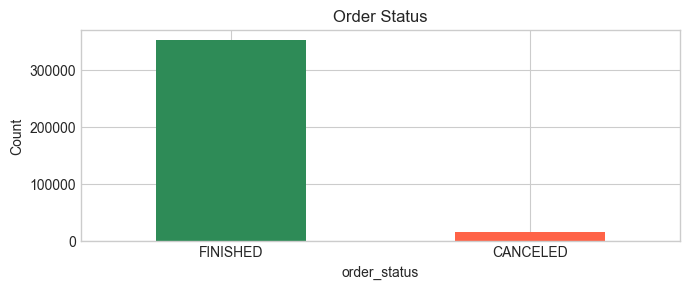

In [32]:
plt.figure(figsize=(7,3))
df['order_status'].value_counts().plot(kind='bar', color=['seagreen','tomato'])
plt.title('Order Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

In [33]:
df['order_amount'].describe(percentiles=[.05,.25,.5,.75,.95,.99])

count    368999.00
mean        105.15
std        2953.11
min           0.00
5%           23.50
25%          39.90
50%          71.60
75%         121.90
95%         247.80
99%         472.84
max     1788306.11
Name: order_amount, dtype: float64

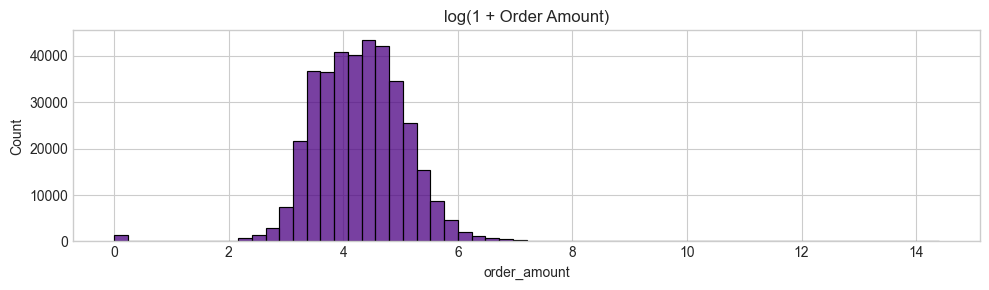

In [34]:
plt.figure(figsize=(10,3))
sns.histplot(np.log1p(df['order_amount']), bins=60, color='indigo')
plt.title('log(1 + Order Amount)')
plt.tight_layout(); plt.show()

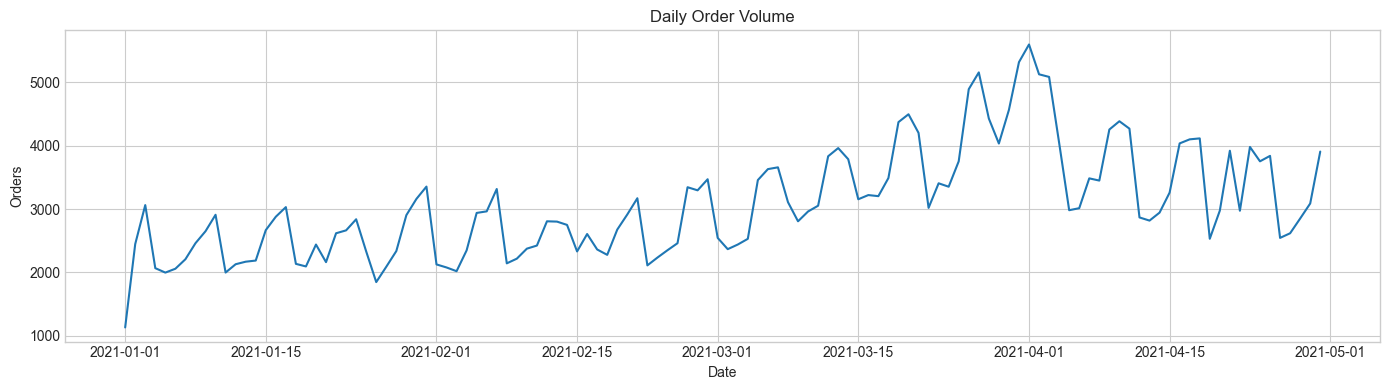

In [35]:
df['date'] = df['order_moment_created'].dt.date
daily = df.groupby('date').size()

plt.figure(figsize=(14,4))
daily.plot()
plt.title('Daily Order Volume')
plt.ylabel('Orders'); plt.xlabel('Date'); plt.tight_layout(); plt.show()

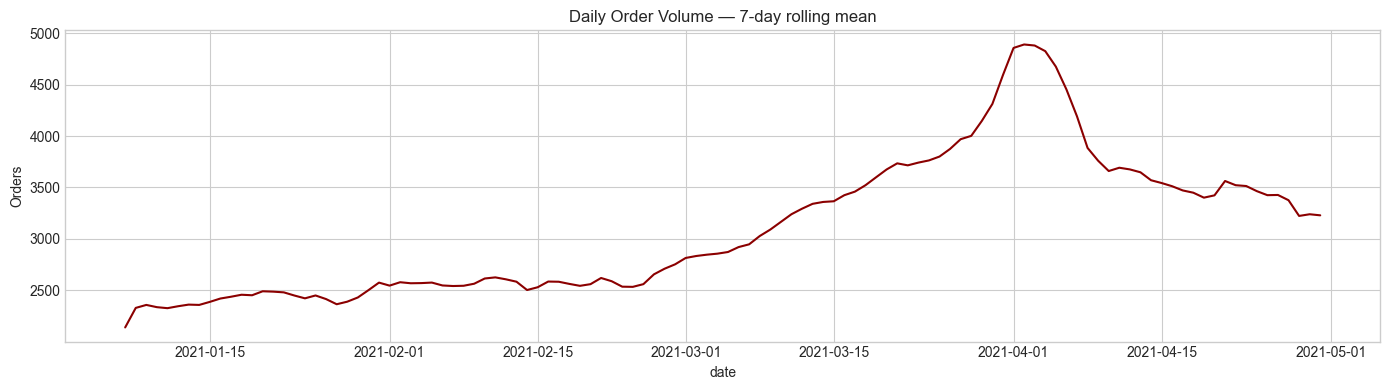

In [36]:
# 7-day rolling to see trend clearly
plt.figure(figsize=(14,4))
daily.rolling(7).mean().plot(color='darkred')
plt.title('Daily Order Volume — 7-day rolling mean')
plt.ylabel('Orders'); plt.tight_layout(); plt.show()

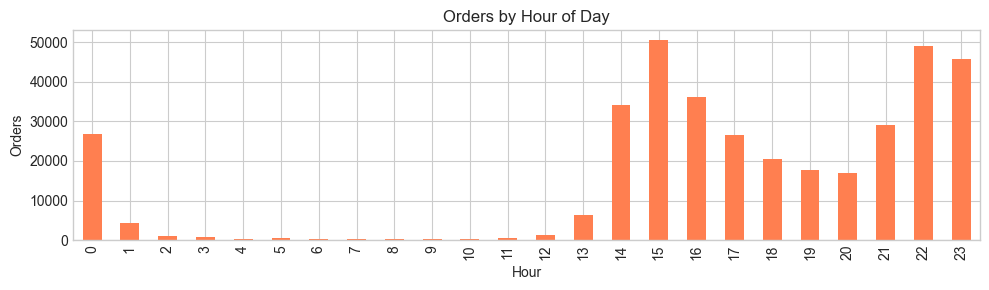

In [37]:
df['hour'] = df['order_moment_created'].dt.hour
hourly_pattern = df.groupby('hour').size()

plt.figure(figsize=(10,3))
hourly_pattern.plot(kind='bar', color='coral')
plt.title('Orders by Hour of Day')
plt.xlabel('Hour'); plt.ylabel('Orders'); plt.tight_layout(); plt.show()

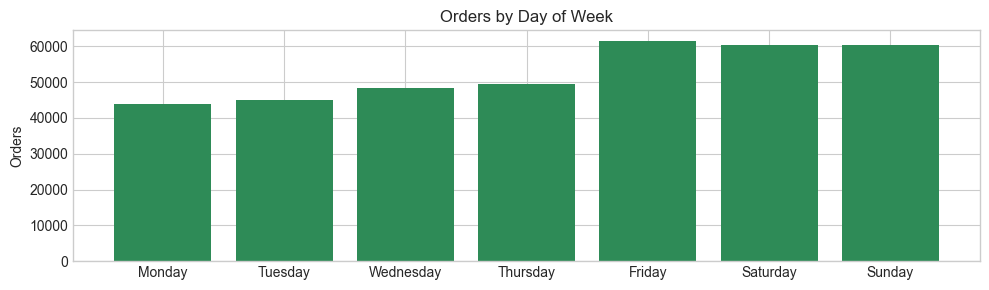

In [38]:
df['dow']      = df['order_moment_created'].dt.dayofweek
df['dow_name'] = df['order_moment_created'].dt.day_name()

dow_pattern = df.groupby(['dow','dow_name']).size().reset_index(name='count').sort_values('dow')

plt.figure(figsize=(10,3))
plt.bar(dow_pattern['dow_name'], dow_pattern['count'], color='seagreen')
plt.title('Orders by Day of Week')
plt.ylabel('Orders'); plt.tight_layout(); plt.show()

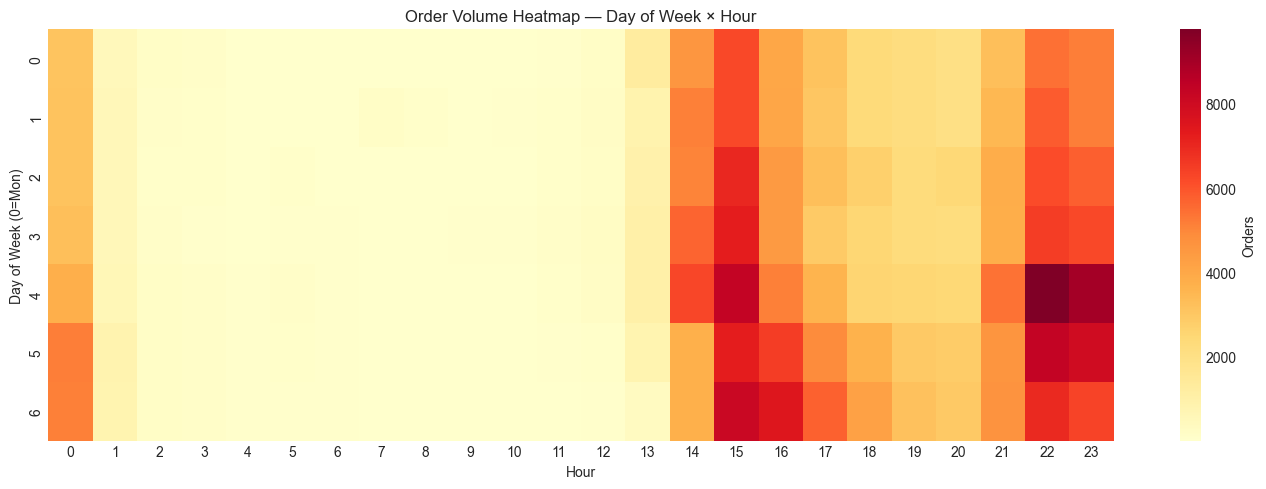

In [39]:
heat = df.groupby(['dow','hour']).size().unstack(fill_value=0)

plt.figure(figsize=(14,5))
sns.heatmap(heat, cmap='YlOrRd', cbar_kws={'label':'Orders'})
plt.title('Order Volume Heatmap — Day of Week × Hour')
plt.xlabel('Hour'); plt.ylabel('Day of Week (0=Mon)'); plt.tight_layout(); plt.show()

In [40]:
hub_volume = df.groupby('hub_name').size().sort_values(ascending=False)
print("Total hubs:", hub_volume.shape[0])
hub_volume.describe()

Total hubs: 32


count      32.00
mean    11531.22
std      9598.66
min         1.00
25%      4718.00
50%     10476.50
75%     17145.75
max     44868.00
dtype: float64

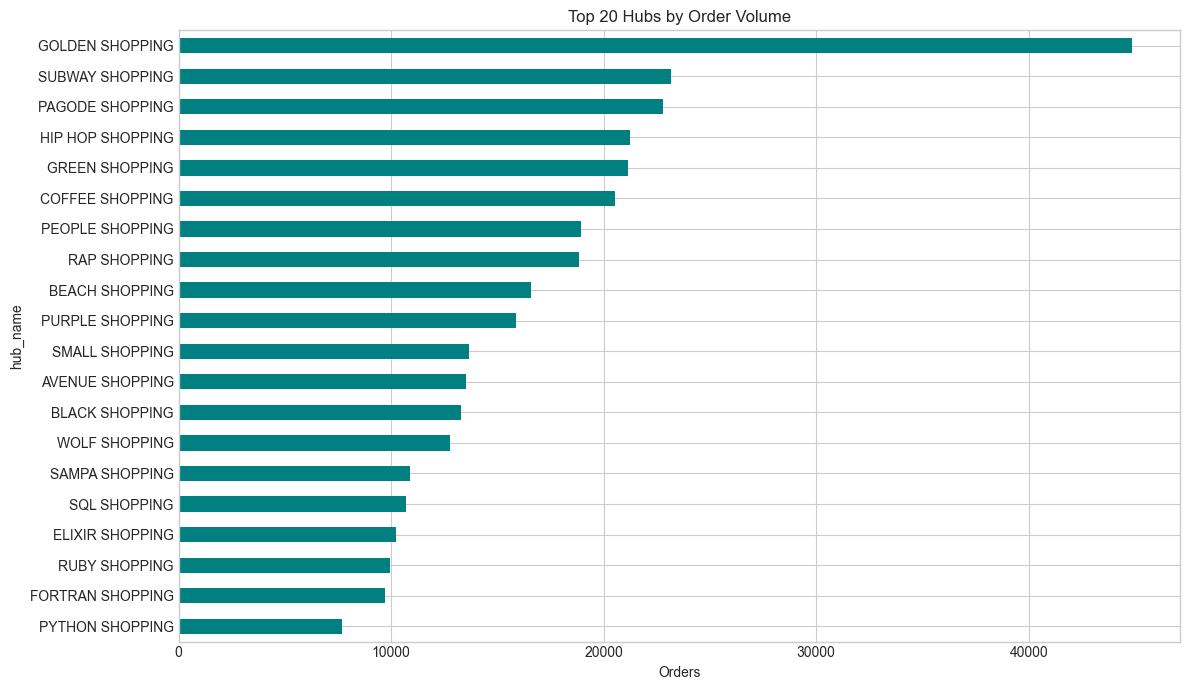

In [41]:
plt.figure(figsize=(12,7))
hub_volume.head(20).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title('Top 20 Hubs by Order Volume')
plt.xlabel('Orders'); plt.tight_layout(); plt.show()

In [42]:
# Concentration: what % of orders come from top 10 hubs?
top10_share = hub_volume.head(10).sum() / hub_volume.sum() * 100
print(f"Top 10 hubs account for {top10_share:.1f}% of orders")

Top 10 hubs account for 60.7% of orders


In [43]:
df.groupby('hub_state').size().sort_values(ascending=False)

hub_state
SP    167590
RJ    137594
RS     34429
PR     29386
dtype: int64

In [44]:
df.groupby('hub_city').size().sort_values(ascending=False).head(10)

hub_city
SÃO PAULO         167590
RIO DE JANEIRO    137594
PORTO ALEGRE       34429
CURITIBA           29386
dtype: int64

In [45]:
df.groupby('store_segment').size().sort_values(ascending=False)

store_segment
FOOD    321775
GOOD     47224
dtype: int64

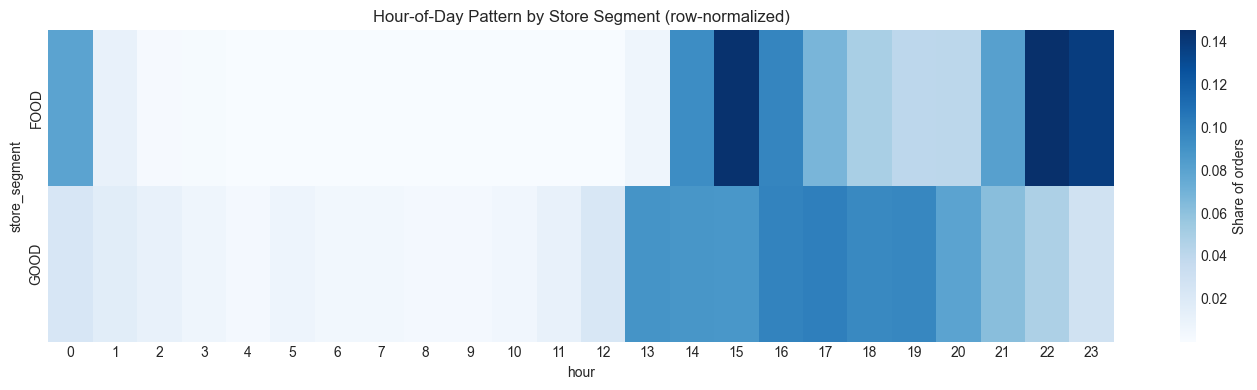

In [46]:
seg_hour = df.groupby(['store_segment','hour']).size().unstack(fill_value=0)
seg_hour_norm = seg_hour.div(seg_hour.sum(axis=1), axis=0)

plt.figure(figsize=(14,4))
sns.heatmap(seg_hour_norm, cmap='Blues', cbar_kws={'label':'Share of orders'})
plt.title('Hour-of-Day Pattern by Store Segment (row-normalized)')
plt.tight_layout(); plt.show()

In [47]:
df.groupby('channel_type').size().sort_values(ascending=False)

channel_type
MARKETPLACE    333165
OWN CHANNEL     35834
dtype: int64

In [48]:
df.groupby('channel_name').size().sort_values(ascending=False).head(10)

channel_name
FOOD PLACE        288723
EATS PLACE         15109
LONDON PLACE       12474
CHOCO PLACE        10367
OTHER PLACE         9204
VELOCITY PLACE      9103
LISBON PLACE        8589
WHATS PLACE         4753
SHOPP PLACE         3222
BRAZIL PLACE        1509
dtype: int64

In [49]:
df['order_metric_cycle_time'].describe(percentiles=[.1,.25,.5,.75,.9,.95,.99])

count   353380.00
mean       156.57
std       1224.99
min          0.33
10%         26.03
25%         32.87
50%         42.23
75%         55.67
90%         83.97
95%        237.52
99%       2709.53
max     154277.32
Name: order_metric_cycle_time, dtype: float64

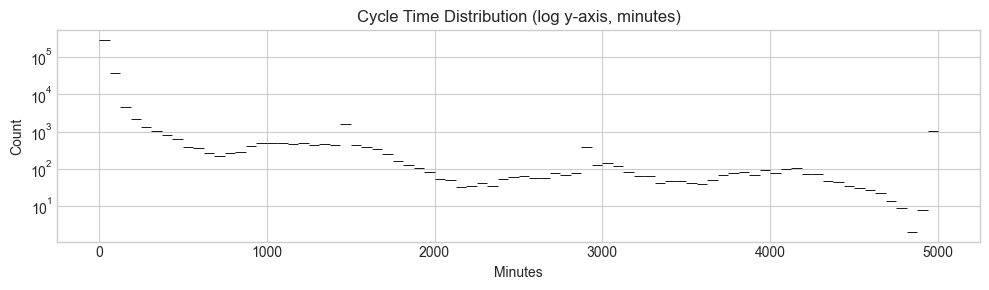

In [50]:
plt.figure(figsize=(10,3))
sns.histplot(df['order_metric_cycle_time'].dropna().clip(1, 5000),
             bins=80, log_scale=(False, True), color='darkorange')
plt.title('Cycle Time Distribution (log y-axis, minutes)')
plt.xlabel('Minutes'); plt.tight_layout(); plt.show()

In [51]:
# Cycle time by segment
df.groupby('store_segment')['order_metric_cycle_time'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
store_segment,,,,,,,,
FOOD,312011.00,67.60,723.50,0.30,32.30,40.90,51.80,154277.30
GOOD,41369.00,827.90,2891.40,0.40,46.60,108.60,770.40,111397.20


Top hub: GOLDEN SHOPPING


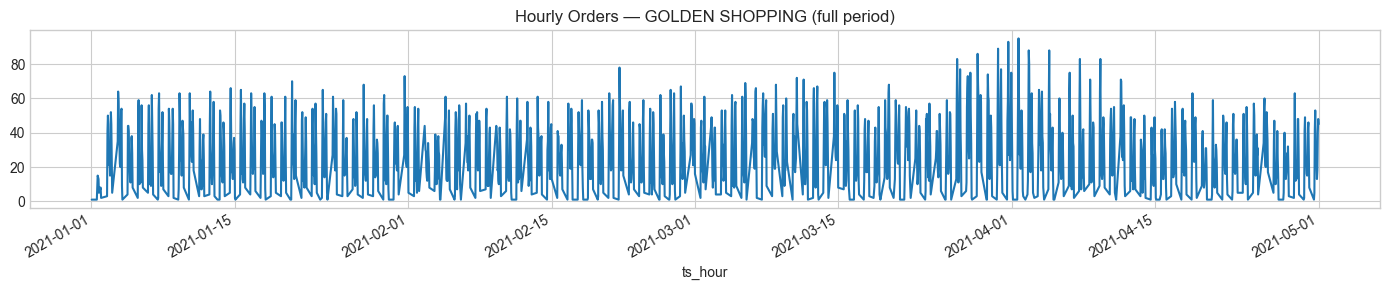

In [52]:
top_hub = hub_volume.index[0]
print("Top hub:", top_hub)

one = df[df['hub_name'] == top_hub].copy()
one['ts_hour'] = one['order_moment_created'].dt.floor('H')
one_hourly = one.groupby('ts_hour').size()

plt.figure(figsize=(14,3))
one_hourly.plot()
plt.title(f'Hourly Orders — {top_hub} (full period)')
plt.tight_layout(); plt.show()

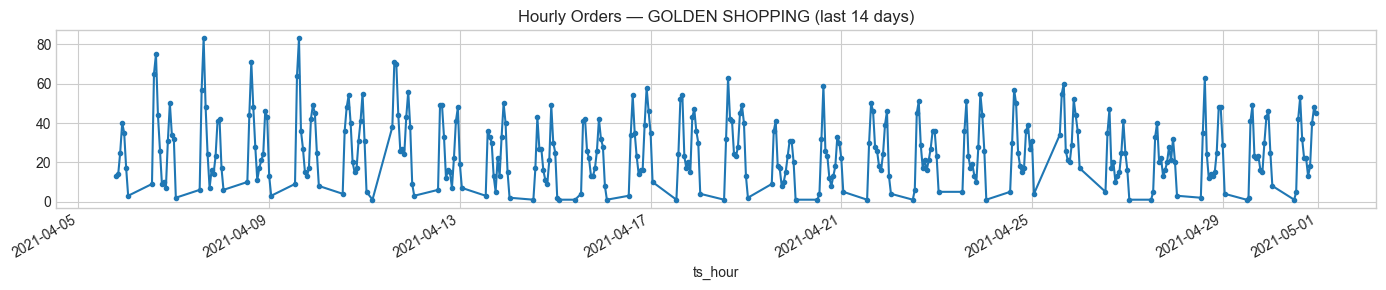

In [53]:
plt.figure(figsize=(14,3))
one_hourly.tail(24*14).plot(marker='o', markersize=3)
plt.title(f'Hourly Orders — {top_hub} (last 14 days)')
plt.tight_layout(); plt.show()

In [54]:
print("=== SUMMARY ===")
print(f"Total orders     : {len(df):,}")
print(f"Finished orders  : {(df['order_status']=='FINISHED').sum():,}")
print(f"Cancelled orders : {(df['order_status']=='CANCELED').sum():,}  ({(df['order_status']=='CANCELED').mean()*100:.2f}%)")
print(f"Unique stores    : {df['store_id'].nunique():,}")
print(f"Unique hubs      : {df['hub_id'].nunique():,}")
print(f"Unique channels  : {df['channel_id'].nunique():,}")
print(f"Date range       : {df['order_moment_created'].min()} → {df['order_moment_created'].max()}")
print(f"Days covered     : {(df['order_moment_created'].max() - df['order_moment_created'].min()).days}")
print(f"Avg orders/day   : {len(df) / max((df['order_moment_created'].max() - df['order_moment_created'].min()).days, 1):.0f}")

=== SUMMARY ===
Total orders     : 368,999
Finished orders  : 352,020
Cancelled orders : 16,979  (4.60%)
Unique stores    : 951
Unique hubs      : 32
Unique channels  : 39
Date range       : 2021-01-01 00:01:36 → 2021-04-30 23:59:48
Days covered     : 119
Avg orders/day   : 3101


In [19]:
df.columns

Index(['order_id', 'store_id', 'channel_id', 'payment_order_id',
       'delivery_order_id', 'order_status', 'order_amount',
       'order_delivery_fee', 'order_delivery_cost', 'order_created_hour',
       'order_created_minute', 'order_created_day', 'order_created_month',
       'order_created_year', 'order_moment_created', 'order_moment_accepted',
       'order_moment_ready', 'order_moment_collected',
       'order_moment_in_expedition', 'order_moment_delivering',
       'order_moment_delivered', 'order_moment_finished',
       'order_metric_collected_time', 'order_metric_paused_time',
       'order_metric_production_time', 'order_metric_walking_time',
       'order_metric_expediton_speed_time', 'order_metric_transit_time',
       'order_metric_cycle_time', 'hub_id', 'store_name', 'store_segment',
       'store_plan_price', 'store_latitude', 'store_longitude', 'hub_name',
       'hub_city', 'hub_state', 'hub_latitude', 'hub_longitude',
       'channel_name', 'channel_type'],
      dt

In [ ]:
# Only keep columns needed for feature engineering & modeling
keep = ['order_id','store_id','hub_id','channel_id',
        'order_status','order_amount',
        'order_moment_created',
        'hub_name','hub_city','hub_state',
        'store_segment','channel_name','channel_type']

df[keep].to_parquet('/Users/anish/Documents/demand forcasting time series /data/raw_clean_for_fetureeng/orders_clean.parquet', index=False)
print("Saved: orders_clean.parquet")

Saved: orders_clean.parquet
